# **KNN con el DataSet IRIS para clasificar diferentes tipos de flores**

Setosa

Versicolor

Virginica

In [9]:
## pryeba
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseValue'] = pd.Series(data.target)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
## pryeba
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
# Paso 1: Importar librerías necesarias
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# **Paso 1: Importar librerías necesarias**

In [ ]:
#df.describe()

# **Paso 2: Cargar y explorar el dataset**
¿Qué hace el siguiente bloque?

1 Carga el dataset iris desde scikit-learn.

2 Guarda los atributos numéricos en X y las etiquetas (clases) en y.

3 Crea un DataFrame con nombres de columnas descriptivos.

4 Añade dos columnas nuevas:

**target:** Colocaremos la clase numérica (0, 1, 2) que indican la clase a la que pertenece cada flor.
Así el modelo sabe que, por ejemplo:

0 → flor del tipo setosa

1 → flor del tipo versicolor

2 → flor del tipo virginica

  + Scikit-learn no trabaja directamente con texto (por ejemplo, “setosa”),
  sino con números que representan categorías.
  Por eso, internamente el dataset Iris codifica cada especie con un número
  **Esto se conoce como codificación de etiquetas (label encoding).**

**species:** El nombre de la especie (setosa, versicolor, virginica)

+ Crea un diccionario con zip(range(3), iris.target_names) → {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

+ Luego, usa .map() para reemplazar los números por su nombre de especie.

 **En palabras simples:**

“Toma la columna target, y cambia los números 0, 1 y 2 por sus nombres reales de especie.”

5 Muestra las primeras filas del conjunto

In [ ]:
# Paso 2: Cargar y explorar el dataset

# Cargar el dataset Iris
iris = load_iris()      # Carga el dataset iris desde scikit-learn.
X = iris.data           # Guarda los atributos numéricos en X .
y = iris.target         # y las etiquetas (clases) en y


# Crear un DataFrame para exploración
df = pd.DataFrame(X, columns=iris.feature_names)                           # Crea un DataFrame con nombres de columnas descriptivos.
df['target'] = y                                                           # Añade una columna nueva llamada: target, con los valores numéricos (0, 1, 2) que indican la clase a la que pertenece cada flor.
df['species'] = df['target'].map(dict(zip(range(3), iris.target_names)))   # Añade otra una columna nueva llamada: species, es el nombre de la especie (setosa, versicolor, virginica))
df.head()                                                                  # Muestra las primeras filas del conjunto


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# **Paso 3: Dividir los datos en entrenamiento y prueba**

Explicación:

train_test_split es una función de scikit-learn que divide los datos en dos partes:

una para entrenar el modelo

otra para evaluar su desempeño

test_size=0.2 significa que el 20 % de los datos se reservarán para la prueba.

random_state=42 garantiza que la división siempre sea igual si vuelves a ejecutar el código.

stratify=y asegura que las tres especies de flores estén representadas proporcionalmente tanto en el conjunto de entrenamiento como en el de prueba (muy importante cuando hay clases múltiples o desbalanceadas).

In [ ]:
# Paso 3: Dividir los datos en entrenamiento y prueba

# Dividimos las variables predictoras (X) y la variable objetivo (y)
# en dos subconjuntos: entrenamiento (train) y prueba (test).
# Esto permite que el modelo aprenda con una parte de los datos
# y luego se evalúe con datos nuevos que no ha visto antes.

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Variables independientes (características)
    y,                  # Variable dependiente (etiquetas o clases)
    test_size=0.2,      # 20% de los datos se usarán para prueba
    random_state=42,    # Fija la semilla aleatoria para reproducibilidad
    stratify=y          # Mantiene la proporción de clases en ambos conjuntos
)

# Resultado:
# X_train → Características para entrenamiento (80%)
# X_test  → Características para prueba (20%)
# y_train → Etiquetas reales del entrenamiento
# y_test  → Etiquetas reales de prueba

# Verificamos la proporción de clases en ambos conjuntos para confirmar que se mantuvieron equilibradas
print("Proporción de clases en el conjunto de entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nProporción de clases en el conjunto de prueba:")
print(pd.Series(y_test).value_counts(normalize=True))


Proporción de clases en el conjunto de entrenamiento:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Proporción de clases en el conjunto de prueba:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


# **Paso 4: Escalar los datos**

En este paso ajustamos la escala de las variables.
KNN mide distancias, y si una variable (como el largo del pétalo) tiene valores mucho mayores que otra (como el ancho del sépalo), el modelo se sesga.
Con StandardScaler, todas las variables se normalizan para que tengan el mismo peso en el cálculo.

In [ ]:
# Paso 4: Escalar los datos

# KNN se basa en la distancia entre puntos, por lo que es importante
# que todas las variables estén en la misma escala.
# Si una variable tiene valores más grandes que otras, dominará el cálculo
# y el modelo no funcionará correctamente.

# Crear el objeto escalador (StandardScaler)
# Este método ajusta los datos restando la media y dividiendo entre la desviación estándar.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Ajustar el escalador con los datos de entrenamiento y transformarlos
# fit_transform: calcula los parámetros de escalado (media y desviación) y transforma los datos

X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando los mismos parámetros del entrenamiento
# transform: aplica la misma transformación, sin volver a calcular medias ni desviaciones

X_test_scaled = scaler.transform(X_test)

# Resultado:
# X_train_scaled y X_test_scaled ahora tienen media ≈ 0 y desviación estándar ≈ 1
# Esto equilibra todas las variables para que ninguna domine en el cálculo de distancias.
# Esto previene que variables con escalas mayores (como el largo del pétalo) dominen el cálculo de distancias.

# **¿Cómo se ven los datos escalados?**

Explicación simple

Cuando decimos que los datos son escalados, significa que sus valores originales fueron transformados para estar en una misma escala numérica.
Esto se hace porque muchos algoritmos de Machine Learning (como KNN, regresión logística o SVM) funcionan mejor cuando todas las variables tienen el mismo rango de valores.

**Antes del escalado**

Cada columna tiene un rango diferente.
Por ejemplo, en tu tabla original:

sepal length va de 4.3 a 7.9

petal width va de 0.1 a 2.5

Eso significa que una variable puede “dominar” a las demás solo porque sus números son más grandes, no porque sea más importante.

**Después del escalado**

Todos los valores fueron convertidos a una escala común, donde:

El promedio (mean) está cerca de 0.

La desviación estándar (std) está cerca de 1.

Esto se logra con un método como StandardScaler() de sklearn, que aplica la fórmula:

𝑧 = 𝑥 − media desviacion estandar /   desviacion estandar





--- Estadísticas originales ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         120.000000        120.000000          120.00000   
mean            5.841667          3.048333            3.77000   
std             0.840926          0.448524            1.76852   
min             4.300000          2.000000            1.10000   
25%             5.100000          2.800000            1.60000   
50%             5.750000          3.000000            4.25000   
75%             6.400000          3.325000            5.10000   
max             7.900000          4.400000            6.90000   

       petal width (cm)  
count        120.000000  
mean           1.205000  
std            0.762663  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

--- Estadísticas después del escalado ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.200000e+02      1.200000e

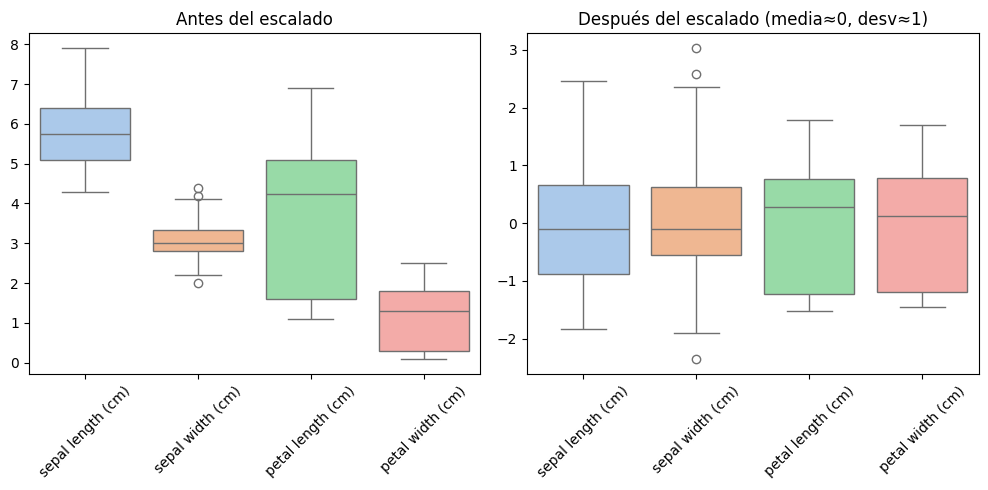

In [ ]:
# Convertimos los arrays en DataFrames para comparar fácilmente
df_train_original = pd.DataFrame(X_train, columns=iris.feature_names)
df_train_escaled = pd.DataFrame(X_train_scaled, columns=iris.feature_names)

# Mostramos estadísticas descriptivas antes y después del escalado
print("\n--- Estadísticas originales ---")
print(df_train_original.describe())

print("\n--- Estadísticas después del escalado ---")
print(df_train_escaled.describe())

# Visualización con Seaborn: comparación variable por variable
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(data=df_train_original, palette="pastel")
plt.title("Antes del escalado")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=df_train_escaled, palette="pastel")
plt.title("Después del escalado (media≈0, desv≈1)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Paso 5: Entrenar el modelo KNN**

Explicación:

En KNN no existe una función matemática que se ajuste (como en regresión lineal),
sino que el modelo memoriza las observaciones y luego compara distancias.

Cada predicción se basa en qué tan cerca están los datos nuevos de los ejemplos conocidos.

El parámetro K (n_neighbors) controla la suavidad del modelo:

+ K pequeño → modelo muy sensible (puede sobreajustarse).

+ K grande → modelo más estable, pero menos preciso en detalles.

In [ ]:
# Paso 5: Entrenar el modelo KNN

# KNN (K-Nearest Neighbors) es un algoritmo supervisado de clasificación
# que clasifica un punto nuevo según las clases de sus k vecinos más cercanos.

# Crear el modelo
# n_neighbors=5 significa que el modelo considerará los 5 vecinos más cercanos
# para decidir la clase de cada observación nueva.

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo con los datos escalados
# fit() almacena los datos de entrenamiento (características y etiquetas)
# El modelo no “aprende” una ecuación, sino que guarda los ejemplos para compararlos
# con futuras observaciones mediante distancias (por eso se llama “perezoso”).

knn.fit(X_train_scaled, y_train)

# Resultado:
# El modelo KNN queda entrenado con las 4 características de cada flor
# y sus respectivas etiquetas (setosa, versicolor, virginica).
# A partir de ahora, puede predecir la especie de una flor nueva
# comparando su distancia con las flores del conjunto de entrenamiento.


KNeighborsClassifier()

# **Paso 6: Predecir con el modelo**

En este paso, el modelo KNN ya ‘conoce’ las flores del conjunto de entrenamiento.

Ahora recibe flores nuevas (del conjunto de prueba), calcula qué tan cerca están
de las flores conocidas y asigna la especie según la mayoría de sus vecinos.

Recordar:

0 → flor del tipo setosa

1 → flor del tipo versicolor

2 → flor del tipo virginica


In [ ]:
# Paso 6: Predecir con el modelo

# En este paso usamos el modelo entrenado (knn) para hacer predicciones
# sobre los datos de prueba (X_test_scaled), que el modelo nunca ha visto antes.

# Realizamos las predicciones
# predict() toma cada fila del conjunto de prueba y busca
# los 5 vecinos más cercanos (porque K=5) en el conjunto de entrenamiento.
# Luego asigna la clase más frecuente entre esos vecinos.

y_pred = knn.predict(X_test_scaled)

# Mostramos las predicciones del modelo
# Cada número corresponde a una clase:
# 0 = setosa, 1 = versicolor, 2 = virginica

print("Predicciones:", y_pred)

# Resultado:
# Un arreglo con las etiquetas predichas por el modelo, por ejemplo:
# [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]

# Estas predicciones se compararán más adelante con las etiquetas reales (y_test)
# para evaluar qué tan bien funcionó el modelo en términos de precisión.


Predicciones: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


# **Paso 7: Visualizar con reducción de dimensiones (opcional)**

PCA (Análisis de Componentes Principales) es una técnica que reduce la cantidad de variables
manteniendo la mayor parte de la información.
En este caso, las 4 variables originales (largo y ancho de sépalo y pétalo)
se reducen a 2 componentes principales para poder graficarlas en 2D.

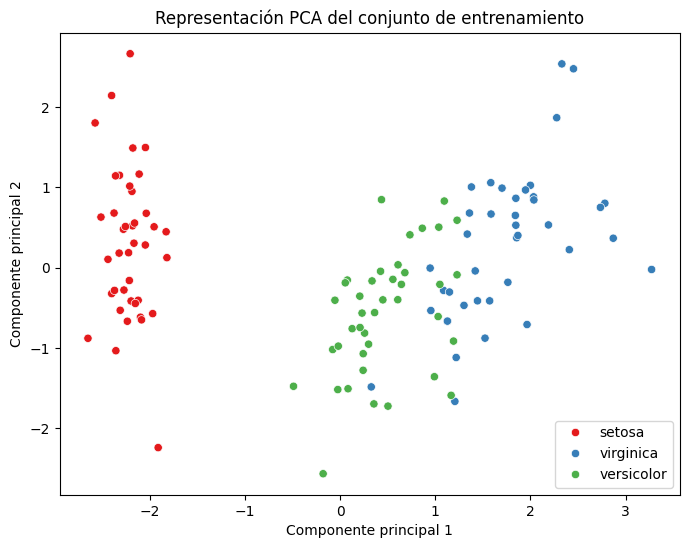

In [ ]:
# Paso 7: Visualizar con reducción de dimensiones (opcional)

# Importamos la clase PCA desde scikit-learn

from sklearn.decomposition import PCA

# Creamos un objeto PCA indicando que queremos 2 componentes principales

pca = PCA(n_components=2)

# Ajustamos el PCA a los datos escalados y los transformamos
# fit_transform() encuentra las combinaciones lineales que explican mejor la varianza
# y transforma los datos originales a este nuevo espacio 2D.

X_reduced = pca.fit_transform(X_train_scaled)

# Creamos la figura para graficar

plt.figure(figsize=(8, 6))

# Graficamos los puntos proyectados en el nuevo espacio de 2 dimensiones
# Cada punto representa una flor, coloreada según su especie.

sns.scatterplot(
    x=X_reduced[:, 0],                # Primer componente principal
    y=X_reduced[:, 1],                # Segundo componente principal
    hue=iris.target_names[y_train],   # Colores por especie
    palette="Set1"                    # Paleta de colores para distinguir clases
)

# Agregamos título y etiquetas a los ejes
plt.title("Representación PCA del conjunto de entrenamiento")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

# Mostramos el gráfico
plt.show()


# **Conclusiones:**

+La reducción de dimensiones con PCA permite visualizar en 2D cómo se distribuyen las especies del dataset Iris, originalmente con 4 variables.

+ Setosa (rojo) se encuentra completamente separada, lo que anticipa una clasificación casi perfecta por parte del modelo KNN.

+ Virginica (azul) está bien agrupada y diferenciada de Setosa, aunque presenta cierta cercanía con Versicolor.

+ Versicolor (verde) ocupa una zona intermedia donde las clases se superponen, lo que explica posibles errores de clasificación.

+ KNN funciona mejor cuando las clases están bien separadas, ya que basa sus decisiones en la distancia entre los puntos.

+ Cuando las clases se solapan, la distancia deja de ser un criterio confiable, y el modelo puede confundirse.

+ Este análisis visual prepara el paso hacia la evaluación del modelo, donde se medirán sus resultados mediante métricas como la matriz de confusión, precisión, recall, F1-score y curva ROC.

# **Métricas de evaluación del modelo K vecinos más cercanos**

# Paso 1: Matriz de confusión

La matriz de confusión permite evaluar el rendimiento del modelo
mostrando cuántas predicciones fueron correctas y cuántas incorrectas.

Cada fila representa las clases reales y cada columna las predicciones del modelo.

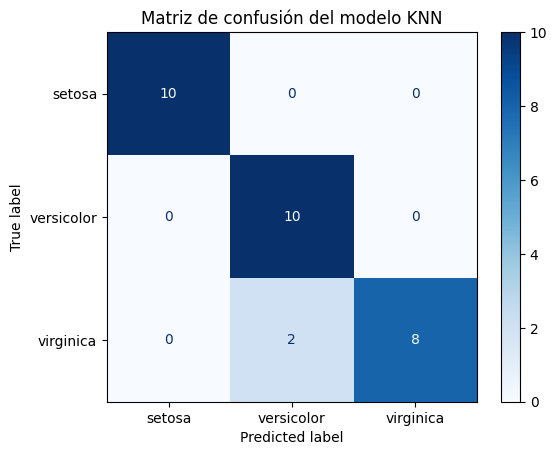

In [ ]:
# Paso 1: Matriz de confusión

# Importamos las funciones necesarias desde sklearn.metrics
# - confusion_matrix: genera la matriz numérica de resultados
# - ConfusionMatrixDisplay: facilita su visualización como gráfico

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generamos la matriz de confusión comparando los valores reales y los predichos
# y_test → etiquetas reales del conjunto de prueba
# y_pred → etiquetas predichas por el modelo

cm = confusion_matrix(y_test, y_pred)

# Creamos un objeto gráfico con las etiquetas de las clases
# display_labels=iris.target_names agrega los nombres de las especies ('setosa', 'versicolor', 'virginica')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)

# Dibujamos la matriz usando un mapa de color (azul) para destacar los valores

disp.plot(cmap=plt.cm.Blues)

# Agregamos un título al gráfico

plt.title("Matriz de confusión del modelo KNN")

# Mostramos la figura
plt.show()


La matriz de confusión nos muestra el desempeño del modelo KNN.

Los valores en la diagonal representan aciertos (predicciones correctas),
mientras que los valores fuera de la diagonal representan errores.

**Si la mayoría de los valores están en la diagonal, significa que el modelo clasifica bien.**

# **Paso 2: Cálculo de precisión general (accuracy)**

La precisión general o accuracy es la proporción de observaciones clasificadas correctamente respecto al total.


La métrica de "accuracy" o precisión general mide
qué porcentaje de las predicciones del modelo fueron correctas. **texto en negrita**


In [ ]:
# Paso 2: Cálculo de precisión general (accuracy)

# Importamos la función accuracy_score desde sklearn.metrics
# Esta función compara las etiquetas reales (y_test) con las predichas (y_pred)
# y devuelve el porcentaje de aciertos totales.

from sklearn.metrics import accuracy_score

# Calculamos la precisión general del modelo KNN

accuracy = accuracy_score(y_test, y_pred)

# Mostramos el resultado con dos decimales
# Ejemplo de salida: "Precisión del modelo KNN: 0.93"

print(f"Precisión del modelo KNN: {accuracy:.2f}")

# Interpretación:
# Un valor de 0.93 significa que el modelo acertó el 93% de las predicciones.
# Cuanto más cerca esté de 1.0, mejor será el rendimiento global del modelo.


Precisión del modelo KNN: 0.93


In [ ]:
# Paso 3: Métricas por clase (Precision, Recall, F1-score)

# Importamos la función necesaria
from sklearn.metrics import classification_report

# Generamos el reporte de clasificación comparando etiquetas reales vs. predichas
report = classification_report(y_test, y_pred, target_names=iris.target_names)

# Mostramos el reporte en consola
print(report)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



Cuando los datos están balanceados, macro y weighted suelen ser iguales.
Pero si hay muchas muestras de una clase y pocas de otra, el weighted avg puede dar un resultado engañosamente alto, porque la clase grande domina el promedio.
En ese caso, conviene revisar cada clase por separado y aplicar técnicas de balanceo como:”

Oversampling: Aumentar ejemplos de la clase minoritaria.

Undersampling: Reducir ejemplos de la clase mayoritaria.


# **Explicacion:**

+ Precision: Mide cuántas veces el modelo acertó cuando predijo una clase.
Ejemplo: Para versicolor (0.83) → de todas las veces que dijo “es versicolor”, acertó el 83 %.

+ Recall: Mide cuántas veces el modelo detectó correctamente los casos reales.
Ejemplo: Virginica (0.80) → el modelo solo detectó 8 de cada 10 virginica reales.

+ F1-score: Equilibrio entre precision y recall.
Un valor alto (cercano a 1) indica un desempeño balanceado.

+ Accuracy: 0.93 → el modelo acertó el 93 % de las predicciones totales.

+ Macro avg: Promedio simple entre las tres clases. En promedio, cada clase fue clasificada con una precisión del 94 % y un F1-score del 93 %

+ Weighted avg: Promedio ponderado según la cantidad de ejemplos por clase. Hay desequilibrio de clases (por ejemplo, si hubiera 100 setosa pero solo 5 virginica).
